W&B 在工程上不仅仅是一个“画曲线的网站”，它是一套完整的 **MLOps（机器学习运维）基础设施**。它的核心体系由四个部分组成：**Runs（实验追踪）**、**Artifacts（产物与版本控制）**、**Sweeps（超参自动化搜索）** 和 **Reports（动态报告）**。

---

## 一、 W&B 的四大核心支柱

### 1. Runs（基础实验追踪）

这是最常用的部分。每一次你运行 `python train.py`，W&B 就会在云端创建一个独一无二的 **Run ID**。这个 Run 会死死盯住你的进程，实时抓取你的指标、系统硬件指标（DDP 模式下甚至能抓取每张卡的显存和通信状态）、控制台的标准输出（`stdout` / `stderr`）以及报错信息。

### 2. Artifacts（模型与数据集版本控制）

这是工业界极度看重的功能。传统的 `torch.save(model.state_dict(), 'best.pt')` 很容易重名或者搞混。
W&B 的 Artifacts 就像是**针对大数据、大模型的 Git**。它可以把你的数据集、训练好的模型 Checkpoint 自动上传到云端，并打上版本号（如 `v0`, `v1`, `latest`），甚至会**自动生成血统图（Lineage Graph）**，清晰地展示“这个模型是用哪一个数据集、哪一次 Run 训练出来的”。

### 3. Sweeps（自动化超参调优）

你不需要自己写 `for` 循环或者用 shell 脚本去试参数。Sweeps 允许你在云端定义一个搜索空间（比如学习率在 `1e-4` 到 `1e-2` 之间，优化器选 `AdamW` 或 `SGD`），W&B 会自动调度你的多台服务器，采用 **贝叶斯优化（Bayesian Optimization）**、**随机搜索** 或 **网格搜索** 自动帮你寻找最优超参组合，并带有**早停机制（Hyperband）**，发现模型跑崩了会自动掐断，省钱省时。

### 4. Reports（团队协作与技术沉淀）

它可以将你不同时期、不同项目跑出来的动态图表一键拖拽组合在一起。你可以在图表旁边写 Markdown Markdown 注释、插入数学公式，生成一个精美的在线网页。




---

## 一、 什么是 Sweeps？

在实际项目中，调参（如试探不同的学习率、Batch Size、优化器）通常是盲目且耗时的。W&B Sweeps 是一套**低代码、分布式、可视化**的自动化调参工具。

它采用 **Master-Workers（中央指挥官 - 分布式打工人）** 架构：

* **Controller（指挥官）**：运行在 W&B 的云端服务器上，负责维护参数账本、生成新参数、决定是否斩杀（剪枝）某个垃圾任务。
* **Agents（打工人）**：运行在你的本地单机、多卡或多台独立的服务器上。Agents 只负责被动领任务、跑训练、报结果。

---

## 二、 核心 API 详解与作用

### 1. 配置注册：`wandb.sweep()`

将你本地定义的调参规则字典（Dict）或者 YAML 文件上传给云端。

```python
sweep_id = wandb.sweep(sweep=sweep_config, project="your_project")

```

* **作用**：在云端初始化一个调参任务，并返回一个唯一的字符串 `sweep_id`。
* **参数空间的三种类型**：
* **固定型**：`{'value': 10}`（所有实验保持一致，如 Epochs）。
* **离散型**：`{'values': ['Adam', 'SGD']}`（从候选列表中随机或遍历挑选）。
* **连续型**：`{'distribution': 'uniform', 'min': 0, 'max': 0.6}`（在区间内按指定概率分布进行采样，常用于 `lr` 或 `dropout`）。



### 2. 派生干活：`wandb.agent()`

在计算节点（显卡/服务器）上点火，启动调参进程。

```python
wandb.agent(sweep_id, function=train, count=5)

```

* **作用**：让本地进程化身成“打工人”。它会连接云端，凭 `sweep_id` 领任务，把领到的参数注入到训练函数中执行，执行完继续领下一个，直到跑满 `count`（尝试次数）为止。

### 3. 被动接受参数：`run.config`

在你的训练函数内部，严禁写死任何超参数，必须统统通过 `run.config` 读取。

```python
run = wandb.init()
current_lr = run.config.lr  # 动态获取本次实验的专属学习率

```

* **作用**：这是 W&B 劫持并控制你训练代码的媒介。

---

## 三、 标准使用流程（三步走）

W&B Sweeps 的标准落地流程极其规范，只需简单的三步：

```text
  1. 定义配置字典 (Dict) ──> 2. 初始化拿到 ID (wandb.sweep) ──> 3. 多卡/多机点火 (wandb.agent)

```

1. **写配置（Define Config）**：
在 Python 里写一个包含 `method`（搜索算法：`random`/`grid`/`bayes`）、`metric`（优化目标：比如最大化验证集准确率）和 `parameters`（超参空间）的字典。
2. **建任务（Create Sweep）**：
调用 `wandb.sweep()` 把字典传上云端，换取一个类似通行证的 `sweep_id`。
3. **点火开跑（Run Agent）**：
把你的核心训练逻辑封装成一个无参函数（例如 `def train():`），然后调用 `wandb.agent(sweep_id, function=train)`。此时，你可以**同时在多个终端、多张显卡、甚至多台服务器**上运行这一行代码，它们会自动协同、分布式地帮你切分并穷举参数空间！

---

## 四、 核心好处与关键痛点

### 💡 核心好处

* **低代码，免维护通信**：如果不用它，你想搞多卡并行调参，需要自己写极其复杂的分布式进程通信、或者写复杂的 Shell 脚本。用 Sweep，你只需要在不同的显卡上启动同一个 python 脚本，云端自动当好“协调员”，绝不打架。
* **Hyperband 自动剪枝（斩杀机制）**：可以配置 `early_terminate`。云端监控发现某组参数训练到第 3 个 Epoch 时的表现极其垃圾，它会**立刻发送终止信号掐断当前实验**，止损算力，立刻切入下一组，极大节省电费和时间。

### ⚠️ 关键痛点

* **必须强联网**：因为调参的“大脑”（Controller）死死长在 W&B 的云端服务器上，如果你的机房是纯局域网、无法访问外网，这套酷炫的自动调参系统将**完全瘫痪，无法运行**。

In [1]:
# =====================================================================
# 0. 【环境守护补丁】强行保住旧版 pydantic_core 的兼容性
# =====================================================================
import pydantic_core
import json
if not hasattr(pydantic_core, 'from_json'):
    pydantic_core.from_json = lambda s: json.loads(s if isinstance(s, str) else s.decode('utf-8'))

import numpy as np
import time
import wandb

# =====================================================================
# 1. 配置 Sweep 调参空间（密码本）
# =====================================================================
sweep_config = {
    # 🔍 搜索算法：'random' (随机搜索), 'grid' (网格穷举), 'bayes' (贝叶斯优化)
    'method': 'random', 
    
    # 🎯 优化目标：告诉云端中央指挥官我们要监控什么指标
    'metric': {
        'name': 'val_acc',
        'goal': 'maximize'   # 我们的目标是让准确率最大化
    },
    
    # ✂️ 【高级功能】：Hyperband 自动剪枝策略
    # 在第 3, 6 个 Epoch 时，如果云端发现这组参数是个“学渣”，直接强制掐断，绝不浪费算力！
    'early_terminate': {
        'type': 'hyperband',
        'min_iter': 3,
        'eta': 2
    },
    
    # 🎲 参与海选的超参数空间
    'parameters': {
        # 固定型参数：指定单值
        'epochs': {'value': 10},
        
        # 离散型参数：从列表中挑选
        'optim_type': {
            'values': ['Adam', 'SGD', 'AdamW']
        },
        'hidden_layer_width': {
            'values': [32, 64, 128]
        },
        
        # 连续型参数：指定概率分布区间
        'lr': {
            'distribution': 'log_uniform_values',
            'min': 1e-4,
            'max': 1e-1
        },
        'dropout_p': {
            'distribution': 'uniform',
            'min': 0.0,
            'max': 0.6
        }
    }
}


In [2]:
# =====================================================================
# 2. 初始化 Sweep Controller（向云端报备，换取唯一指挥官 ID）
# =====================================================================
# 这一步会把配置单传上云端，返回一个类似任务通行证的加密字符串
sweep_id = wandb.sweep(sweep=sweep_config, project="learn_wandb")        

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/zhangjinrui/.netrc.


Create sweep with ID: x4wuqtif
Sweep URL: https://wandb.ai/Jerry-Auto/learn_wandb/sweeps/x4wuqtif


In [3]:
# =====================================================================
# 3. 编写核心训练函数（打工人执行的具体业务）
# =====================================================================
def train_agent_job():
    """
    【安全规范】：函数不能有任何形参。
    每次被 wandb.agent 调用时，都会自动开启一个全新的 online 联机 Run。
    """
    # 启动联机 Run
    run = wandb.init(
        entity="Jerry-Auto",
        project="learn_wandb",
        name="sweep_agent_job"
    )
    
    # 💡 【核心重构】：严禁使用本地写死的变量！
    # 必须直接从当前的 run.config 中动态读取云端下发给你的本次实验参数
    cfg = run.config
    
    print(f"\n🏃 Agent 领到新任务！当前组合 -> 优化器: {cfg.optim_type}, 宽度: {cfg.hidden_layer_width}, lr: {cfg.lr:.5f}")
    
    best_acc = 0.0
    
    # 模拟真实 Epoch 迭代
    for epoch in range(1, cfg.epochs + 1):
        time.sleep(0.3)  # 模拟由于矩阵运算导致的硬件耗时
        
        # 🎲 模拟一个符合科学规律的数学公式来产生 Accuracy：
        # 假设 宽度为128、优化器是 AdamW、且学习率在 0.005 附近时效果最好
        lr_distance = np.abs(cfg.lr - 0.005)
        base_acc = 0.85 if cfg.optim_type == 'AdamW' else 0.60
        if cfg.hidden_layer_width == 128: base_acc += 0.08
        
        # 随着 epoch 推进逐渐收敛，并加入随机扰动噪声
        mock_val_acc = base_acc - (lr_distance * 5) - (0.3 / epoch) + np.random.normal(0, 0.02)
        mock_val_acc = float(np.clip(mock_val_acc, 0.0, 1.0)) # 限制在 0-1 之间
        
        if mock_val_acc > best_acc:
            best_acc = mock_val_acc
            
        print(f"  Epoch 【{epoch}/{cfg.epochs}】: val_acc = {mock_val_acc*100:.2f}%")
        
        # ✍️ 实时把指标汇报给云端中央指挥官
        # 中央指挥官拿到这个指标后，会在后台用 Hyperband 算法评估你是不是学渣，从而决定要不要斩杀你
        wandb.log({
            'epoch': epoch, 
            'val_acc': mock_val_acc, 
            'best_val_acc': best_acc
        })
        
    run.finish()


In [4]:
# =====================================================================
# 4. 点火：启动 Agent 进程开始干活
# =====================================================================
# count=4 代表当前这个终端的打工人会连续跑 4 次实验
# 💡 分布式神技：如果你把这个 python 脚本复制到你的另外 3 台服务器上同时运行，
# 只要传入同一个 sweep_id，它们会像联机网游一样，4台机器同时疯狂帮你调参，绝不撞车！
wandb.agent(sweep_id, function=train_agent_job, count=4)

wandb: Agent Starting Run: b0mdcxvr with config:
wandb: 	dropout_p: 0.3222999287487384
wandb: 	epochs: 10
wandb: 	hidden_layer_width: 128
wandb: 	lr: 0.0016760588457576284
wandb: 	optim_type: Adam
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/zhangjinrui/.netrc.
wandb: Currently logged in as: 1763287396 (Jerry-Auto) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/home/zhangjinrui/anaconda3/envs/flow_planner/lib/python3.9/site-packages/pydantic/main.py:301: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(



🏃 Agent 领到新任务！当前组合 -> 优化器: Adam, 宽度: 128, lr: 0.00168
  Epoch 【1/10】: val_acc = 36.65%
  Epoch 【2/10】: val_acc = 50.02%
  Epoch 【3/10】: val_acc = 56.56%
  Epoch 【4/10】: val_acc = 62.46%
  Epoch 【5/10】: val_acc = 60.95%
  Epoch 【6/10】: val_acc = 62.36%
  Epoch 【7/10】: val_acc = 64.16%
  Epoch 【8/10】: val_acc = 63.16%
  Epoch 【9/10】: val_acc = 62.67%
  Epoch 【10/10】: val_acc = 58.32%


best_val_acc,▁▄▆███████
epoch,▁▂▃▃▄▅▆▆▇█
val_acc,▁▄▆█▇████▇
best_val_acc,0.6416
epoch,10
val_acc,0.58321


wandb: Agent Starting Run: 4drkldyh with config:
wandb: 	dropout_p: 0.4881412472275159
wandb: 	epochs: 10
wandb: 	hidden_layer_width: 32
wandb: 	lr: 0.006276957988829608
wandb: 	optim_type: AdamW
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/zhangjinrui/.netrc.


...

best_val_acc,▁▅▆▆▇▇████
epoch,▁▂▃▃▄▅▆▆▇█
val_acc,▁▅▆▆▇▆████
best_val_acc,0.2558
epoch,10
val_acc,0.25187


wandb: Agent Starting Run: 58rm4rof with config:
wandb: 	dropout_p: 0.43724406775047514
wandb: 	epochs: 10
wandb: 	hidden_layer_width: 128
wandb: 	lr: 0.009711666740300974
wandb: 	optim_type: AdamW
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/zhangjinrui/.netrc.


/home/zhangjinrui/anaconda3/envs/flow_planner/lib/python3.9/site-packages/pydantic/main.py:301: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(



🏃 Agent 领到新任务！当前组合 -> 优化器: AdamW, 宽度: 128, lr: 0.00971
  Epoch 【1/10】: val_acc = 61.67%
  Epoch 【2/10】: val_acc = 77.24%
  Epoch 【3/10】: val_acc = 79.81%
  Epoch 【4/10】: val_acc = 83.67%
  Epoch 【5/10】: val_acc = 80.91%
  Epoch 【6/10】: val_acc = 87.50%
  Epoch 【7/10】: val_acc = 89.58%
  Epoch 【8/10】: val_acc = 85.65%
  Epoch 【9/10】: val_acc = 89.27%
  Epoch 【10/10】: val_acc = 89.45%


best_val_acc,▁▅▆▇▇▇████
epoch,▁▂▃▃▄▅▆▆▇█
val_acc,▁▅▆▇▆▇█▇██
best_val_acc,0.89582
epoch,10
val_acc,0.89452



---

## 🏃 表面上：代码的执行流水线

当你按下运行键，代码会像流水线一样一步步往下走：

1. **第一步：上传密码本**
代码读取你的 `sweep_config`（里面规定了参数范围），并调起 `wandb.sweep()`。它像是在对云端说：“老大，这是我这次调参的范围，你帮我建个档案。”
2. **第二步：拿到大印 (Sweep ID)**
云端收到密码本后，在网页上给你开辟了一个专属的调参看板，并丢回一串加密字符串（如 `sweep_id = "53wjom6j"`）。
3. **第三步：打工人（Agent）上线**
代码走到最后一行 `wandb.agent(...)`。这时候，你的本地进程正式化身为“无情的打工机器”，开始一口气连跑 4 组实验。

---

## 🔄 背后里：Agent 内部的 4 次高频互动

在 `wandb.agent` 连续跑 4 次实验的过程中，你的本地电脑和 W&B 云端一直在进行高频的**对账和通信**：

* **交互 1：请示任务**
本地 Agent 敲敲云端的门：“老大，我空出来了，第一组参数我该跑啥？”
* **交互 2：参数注入**
云端大脑（Controller）经过算法计算，通过网络发来一组随机参数（比如 `lr=0.01, optim_type='AdamW'`）。本地代码里的 `run.config` 瞬间**被动变成**了这组值。
* **交互 3：假装训练与汇报**
本地函数拿着这组参数开始跑 Epoch 循环（用 NumPy 模拟算 Accuracy）。每跑完一个 Epoch，就用 `wandb.log()` 往云端发一次成绩单：“老大，第 3 个 Epoch 准确率是 75%。”
* **交互 4：云端斩杀（关键点！）**
云端指挥官死死盯着传上来的成绩单。如果发现这组参数在第 3 个 Epoch 的表现太差，云端会**直接原地下达“斩杀”指令**。本地循环收到指令后，连 10 个 Epoch 都没跑满，就会强制提前中断（Finish），立刻回到【交互 1】去要下一组参数。

---

## 📌 总结一句话

这段代码在干的事，就是**让本地电脑变成一个“只管算账、被动听指挥”的执行单元，由云端服务器隔空操纵它，连续换了 4 种参数组合去测试表现，同时在网页上把表现画成图表。**

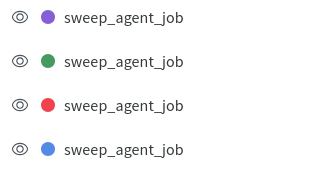

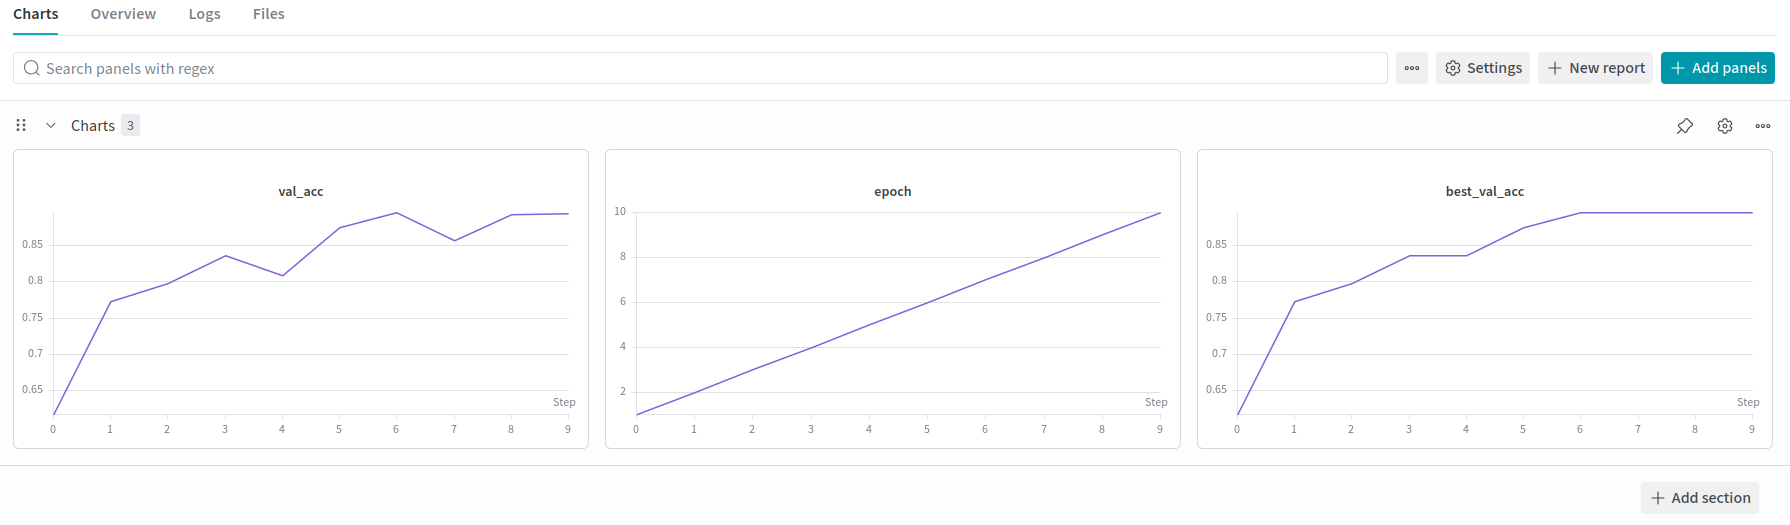